# AT&T CNN avec Layer GRU

In [1]:
import io
import re
import string
import tensorflow as tf
import tqdm
import os
import shutil
import pandas as pd
import numpy as np
from tensorflow.keras import Model
from tensorflow.keras.layers import Dot, Embedding, Flatten
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import os

import warnings
warnings.filterwarnings('ignore')


2025-09-06 12:51:15.887605: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import chardet
import requests

url = "https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Deep+Learning/project/spam.csv"
response = requests.get(url)

# Vérifier si la requête a réussi
if response.status_code == 200:
    rawdata = response.content  # Obtenir les données en bytes
    result = chardet.detect(rawdata[:100000])  # Détecter l'encodage
    print(result)
else:
    print("Échec du téléchargement du fichier :", response.status_code)

{'encoding': 'Windows-1252', 'confidence': 0.7272080023536335, 'language': ''}


In [3]:
df = pd.read_csv("https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Deep+Learning/project/spam.csv",encoding='Windows-1252')

In [4]:
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [5]:
# Préparation des données et suppression des colonnes vides
df = df[['v1', 'v2']]
df = df.rename(columns={'v1': 'Target', 'v2': 'SMS'})
df['Target'] = df['Target'].replace(to_replace=["ham"], value=0)
df['Target'] = df['Target'].replace(to_replace=["spam"], value=1)

In [6]:
# Preprocessing NLP
import spacy
import en_core_web_sm
nlp = en_core_web_sm.load()
from spacy.lang.en.stop_words import STOP_WORDS as EN_STOP_WORDS

df["SMS_Clean"] = df["SMS"].apply(lambda x: ''.join(ch for ch in x if ch.isalnum() or ch == " " or ch == "'"))
df["SMS_Clean"] = df["SMS_Clean"].apply(lambda x: x.replace(" +", " ").lower().strip())
df["SMS_Clean"] = df["SMS_Clean"].apply(lambda x: " ".join([token.lemma_ for token in nlp(x) if (token.lemma_ not in EN_STOP_WORDS) and (token.text not in EN_STOP_WORDS)]))

# Filtrer les valeurs non-string si nécessaire
mask = df.SMS_Clean.apply(lambda x: type(x) == str)
df = df[mask]

In [7]:
from sklearn.model_selection import train_test_split
X_train_text, X_val_text, y_train, y_val = train_test_split(
    df.SMS_Clean, df.Target, test_size=0.3, random_state=42, stratify=df.Target
)

In [8]:
# Tokenization UNIQUEMENT sur les données d'entraînement
import tensorflow as tf
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)  # ✅ Seulement sur train

# Encodage des données
X_train_encoded = tokenizer.texts_to_sequences(X_train_text)
X_val_encoded = tokenizer.texts_to_sequences(X_val_text)



In [9]:
# 🔧 Padding avec longueur optimale
lengths = [len(seq) for seq in X_train_encoded]
max_length = int(np.percentile(lengths, 95))  # Utiliser 95e percentile au lieu de max
print(f"📏 Longueur max choisie: {max_length}")

X_train_pad = tf.keras.preprocessing.sequence.pad_sequences(
    X_train_encoded, maxlen=max_length, padding="post", truncating="post"
)
X_val_pad = tf.keras.preprocessing.sequence.pad_sequences(
    X_val_encoded, maxlen=max_length, padding="post", truncating="post"
)

📏 Longueur max choisie: 20


# OverSampling avec option : "full", "partial", "factor", "none"

In [ ]:

STRATEGY = "partial"  
TARGET_RATIO = 0.3    # Pour partial: ratio de la classe minoritaire
FACTOR = 3.0          # Pour factor: multiplier la classe minoritaire

# Préparation des données
y_train_array = np.array(y_train)
ham_mask = y_train_array == 0
spam_mask = y_train_array == 1

ham_data, spam_data = X_train_pad[ham_mask], X_train_pad[spam_mask]
ham_labels, spam_labels = y_train_array[ham_mask], y_train_array[spam_mask]

print(f"📊 Original: {len(ham_data)} HAM, {len(spam_data)} SPAM")

# Déterminer la classe minoritaire et calculer les cibles
is_spam_minority = len(spam_data) < len(ham_data)
minority_count = min(len(ham_data), len(spam_data))
majority_count = max(len(ham_data), len(spam_data))

if STRATEGY == "full":
    target_minority = majority_count
elif STRATEGY == "partial":
    target_minority = int(TARGET_RATIO * majority_count / (1 - TARGET_RATIO))
elif STRATEGY == "factor":
    target_minority = int(minority_count * FACTOR)
else:  # "none"
    target_minority = minority_count

# Appliquer le rééquilibrage
if target_minority > minority_count and STRATEGY != "none":
    if is_spam_minority:
        spam_resampled = resample(spam_data, n_samples=target_minority, random_state=42)
        labels_resampled = resample(spam_labels, n_samples=target_minority, random_state=42)
        X_train_balanced = np.vstack([ham_data, spam_resampled])
        y_train_balanced = np.concatenate([ham_labels, labels_resampled])
    else:
        ham_resampled = resample(ham_data, n_samples=target_minority, random_state=42)
        labels_resampled = resample(ham_labels, n_samples=target_minority, random_state=42)
        X_train_balanced = np.vstack([ham_resampled, spam_data])
        y_train_balanced = np.concatenate([labels_resampled, spam_labels])
else:
    X_train_balanced = X_train_pad
    y_train_balanced = y_train_array

# Résultats
final_ham = np.sum(y_train_balanced == 0)
final_spam = np.sum(y_train_balanced == 1)
total = len(y_train_balanced)

print(f"📊 Final: {final_ham} HAM ({final_ham/total*100:.1f}%), {final_spam} SPAM ({final_spam/total*100:.1f}%)")

if STRATEGY != "none" and target_minority > minority_count:
    increase = (target_minority - minority_count) / minority_count * 100
    minority_class = "SPAM" if is_spam_minority else "HAM"
    print(f"📈 {minority_class} augmenté de {increase:.1f}% (×{target_minority/minority_count:.1f})")

📊 Original: 3377 HAM, 523 SPAM
📊 Final: 3377 HAM (70.0%), 1447 SPAM (30.0%)
📈 SPAM augmenté de 176.7% (×2.8)


# Model CNN avec layer GRU (variante de LSTM)

In [ ]:
BATCH_SIZE = 32  
BUFFER_SIZE = 1000

train_dataset = tf.data.Dataset.from_tensor_slices((X_train_balanced, y_train_balanced))
val_dataset = tf.data.Dataset.from_tensor_slices((X_val_pad, y_val))

train_batch = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_batch = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

vocab_size = min(len(tokenizer.word_index) + 1, 10000)
embedding_dim = 64
print(f"📚 Taille vocabulaire: {vocab_size}")

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
    tf.keras.layers.SpatialDropout1D(0.2),  # Dropout spécifique aux embeddings
    tf.keras.layers.GRU(64, dropout=0.3, recurrent_dropout=0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

print("🔨 Construction du modèle...")
model.build(input_shape=(None, max_length))

📚 Taille vocabulaire: 6722
🔨 Construction du modèle...


In [ ]:
print("🏗️ Architecture du modèle:")
model.summary()

🏗️ Architecture du modèle:


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 20, 64)         │       430,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_5             │ (None, 20, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,281 (1.74 MB)

 Trainable params: 457,281 (1.74 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# Optimizer

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),  # LR plus élevé au début
    loss="binary_crossentropy",
    metrics=["accuracy", 
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")]
)


In [ ]:
# Callbacks 
os.makedirs('models', exist_ok=True)

callbacks_list = [
    ModelCheckpoint(
        filepath='models/best_spam_model_GRU.h5',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=15,  
        restore_best_weights=True,
        verbose=1,
        min_delta=0.001
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,  
        min_lr=1e-6,
        verbose=1,
        cooldown=2
    )
]

print("📋 Callbacks configurés avec des paramètres plus réactifs")

print("🚀 Démarrage de l'entraînement...")

try:
    history = model.fit(
        train_batch,
        epochs=100, 
        validation_data=val_batch,
        callbacks=callbacks_list,
        verbose=1
    )
    
    print("\n🎯 Entraînement terminé avec succès!")
    
    # Charger et évaluer le meilleur modèle
    print("🔄 Chargement du meilleur modèle...")
    best_model = tf.keras.models.load_model('models/best_spam_model_GRU.h5')
    
    print("\n📊 Évaluation finale:")
    final_results = best_model.evaluate(val_batch, verbose=0)
    
    for name, value in zip(best_model.metrics_names, final_results):
        print(f"  • {name}: {value:.4f}")
        
    # Fonction de prédiction
    def predict_spam(text):
        """Prédire si un SMS est spam"""
        cleaned = clean_text(text)
        sequence = tokenizer.texts_to_sequences([cleaned])
        padded = tf.keras.preprocessing.sequence.pad_sequences(
            sequence, maxlen=max_length, padding="post", truncating="post"
        )
        prediction = best_model.predict(padded, verbose=0)[0][0]
        return "SPAM" if prediction > 0.5 else "HAM", prediction
    
    print("\n✅ Modèle prêt à l'utilisation!")
    print("Utilisez predict_spam('votre message') pour tester")
    
except Exception as e:
    print(f"❌ Erreur pendant l'entraînement: {e}")
    print("Vérifiez vos données et la configuration")

📋 Callbacks configurés avec des paramètres plus réactifs
🚀 Démarrage de l'entraînement...
Epoch 1/100
148/151 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9066 - auc: 0.3292 - loss: 0.3910 - precision: 0.1870 - recall: 0.1295
Epoch 1: val_auc improved from None to 0.28880, saving model to models/best_spam_model_GRU.h5


151/151 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.8367 - auc: 0.8665 - loss: 0.5075 - precision: 0.7389 - recall: 0.7042 - val_accuracy: 0.1340 - val_auc: 0.2888 - val_loss: 1.4114 - val_precision: 0.1340 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/100
149/151 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6244 - auc: 0.2717 - loss: 0.6438 - precision: 0.0921 - recall: 0.0797
Epoch 2: val_auc improved from 0.28880 to 0.95845, saving model to models/best_spam_model_GRU.h5


151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7152 - auc: 0.7596 - loss: 0.5388 - precision: 0.5318 - recall: 0.4216 - val_accuracy: 0.8409 - val_auc: 0.9585 - val_loss: 0.6870 - val_precision: 0.4535 - val_recall: 0.9152 - learning_rate: 0.0010
Epoch 3/100
149/151 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9522 - auc: 0.4101 - loss: 0.3561 - precision: 0.3780 - recall: 0.3444
Epoch 3: val_auc improved from 0.95845 to 0.98586, saving model to models/best_spam_model_GRU.h5


151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9623 - auc: 0.9562 - loss: 0.2299 - precision: 0.9600 - recall: 0.9122 - val_accuracy: 0.9611 - val_auc: 0.9859 - val_loss: 0.1717 - val_precision: 0.8023 - val_recall: 0.9420 - learning_rate: 0.0010
Epoch 4/100
150/151 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9899 - auc: 0.4828 - loss: 0.0798 - precision: 0.4491 - recall: 0.4665
Epoch 4: val_auc did not improve from 0.98586
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9915 - auc: 0.9948 - loss: 0.0544 - precision: 0.9868 - recall: 0.9848 - val_accuracy: 0.9773 - val_auc: 0.9732 - val_loss: 0.0883 - val_precision: 0.8974 - val_recall: 0.9375 - learning_rate: 0.0010
Epoch 5/100
148/151 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9944 - auc: 0.4972 - loss: 0.0362 - precision: 0.4643 - recall: 0.4948
Epoch 5: val_auc did not improve from 0.98586
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9965 - auc: 0.9969 - loss: 0.0268 - precision: 0.9945 - recall


🎯 Entraînement terminé avec succès!
🔄 Chargement du meilleur modèle...

📊 Évaluation finale:
  • loss: 0.1717
  • compile_metrics: 0.9611

✅ Modèle prêt à l'utilisation!
Utilisez predict_spam('votre message') pour tester


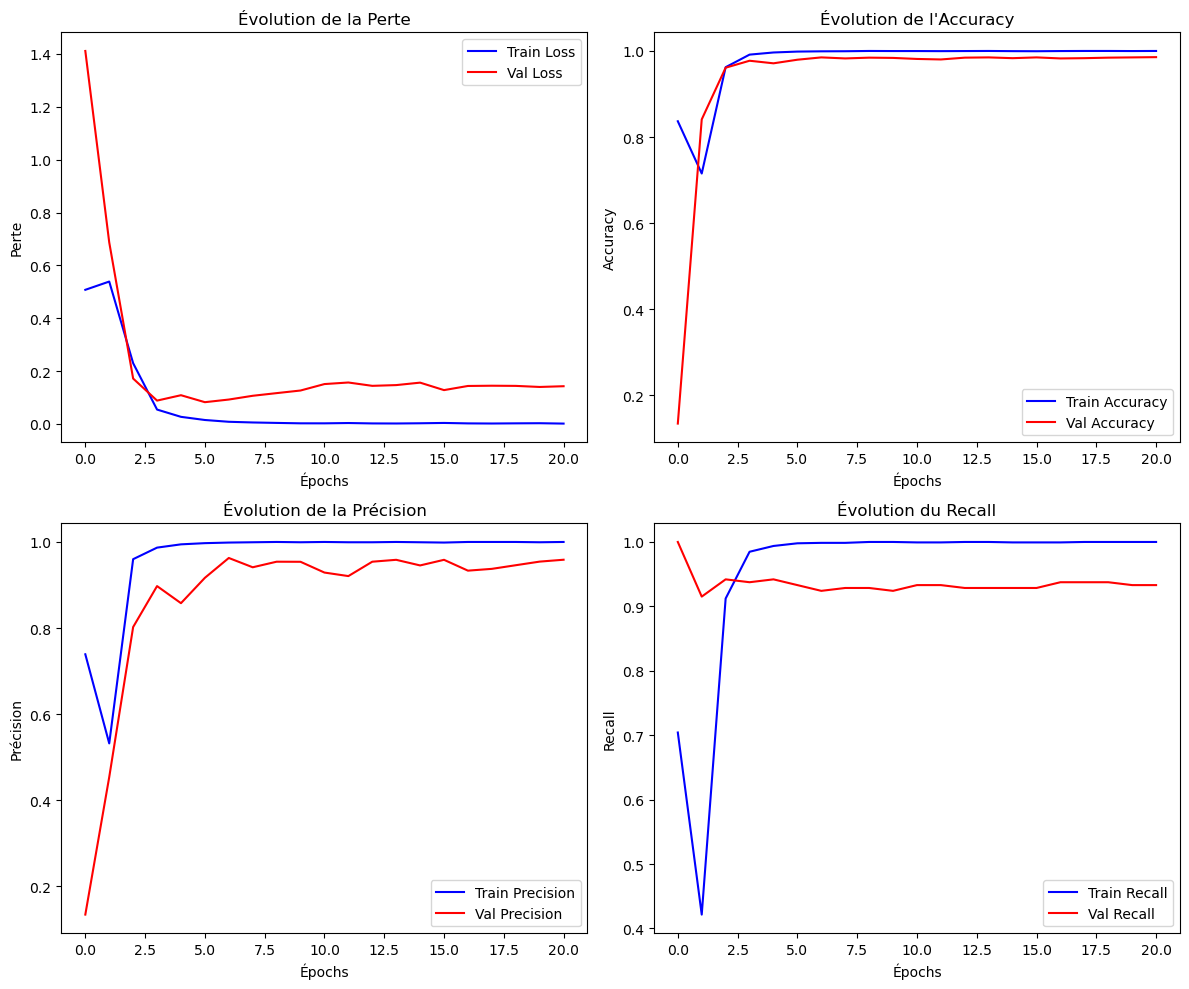

In [ ]:
import matplotlib.pyplot as plt

# Récupération de l'historique de l'entraînement
history_dict = history.history

# Création des subplots
plt.figure(figsize=(12, 10))

# Courbe de la perte (Loss)
plt.subplot(2, 2, 1)
plt.plot(history_dict["loss"], label="Train Loss", color="blue")
plt.plot(history_dict["val_loss"], label="Val Loss", color="red")
plt.xlabel("Épochs")
plt.ylabel("Perte")
plt.legend()
plt.title("Évolution de la Perte")

# Courbe de l'accuracy
plt.subplot(2, 2, 2)
plt.plot(history_dict["accuracy"], label="Train Accuracy", color="blue")
plt.plot(history_dict["val_accuracy"], label="Val Accuracy", color="red")
plt.xlabel("Épochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Évolution de l'Accuracy")

# Courbe de la Précision
plt.subplot(2, 2, 3)
plt.plot(history_dict["precision"], label="Train Precision", color="blue")
plt.plot(history_dict["val_precision"], label="Val Precision", color="red")
plt.xlabel("Épochs")
plt.ylabel("Précision")
plt.legend()
plt.title("Évolution de la Précision")

# Courbe du Recall
plt.subplot(2, 2, 4)
plt.plot(history_dict["recall"], label="Train Recall", color="blue")
plt.plot(history_dict["val_recall"], label="Val Recall", color="red")
plt.xlabel("Épochs")
plt.ylabel("Recall")
plt.legend()
plt.title("Évolution du Recall")

# Affichage des courbes
plt.tight_layout()
plt.show()


53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


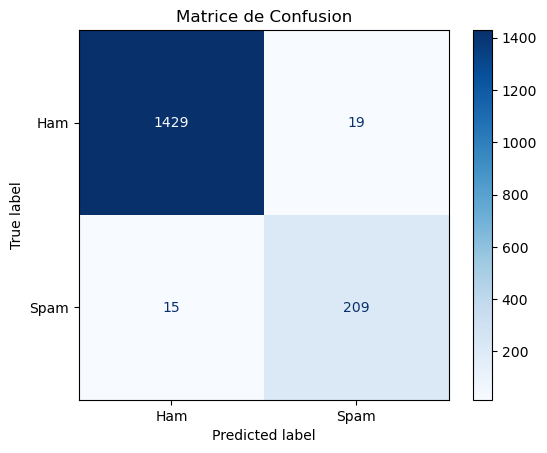

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99      1448
        Spam       0.92      0.93      0.92       224

    accuracy                           0.98      1672
   macro avg       0.95      0.96      0.96      1672
weighted avg       0.98      0.98      0.98      1672



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Prédire les classes pour les données de validation
y_pred = model.predict(X_val_pad)
y_pred_classes = (y_pred > 0.5).astype(int)

# Calculer la matrice de confusion
cm = confusion_matrix(y_val, y_pred_classes)

# Afficher la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ham", "Spam"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice de Confusion")
plt.show()

# Calculer et afficher les métriques
print("Classification Report:")
print(classification_report(y_val, y_pred_classes, target_names=["Ham", "Spam"]))


In [ ]:
import numpy as np

def predict_text(text, model, tokenizer, max_len):
    # Prétraitement du texte
    text_clean = ''.join(ch for ch in text if ch.isalnum() or ch == " " or ch == "'")
    text_clean = text_clean.replace(" +", " ").lower().strip()
    text_clean = " ".join([token.lemma_ for token in nlp(text_clean) if (token.lemma_ not in STOP_WORDS) and (token.text not in STOP_WORDS)])

    # Tokenization et padding
    text_encoded = tokenizer.texts_to_sequences([text_clean])
    text_padded = tf.keras.preprocessing.sequence.pad_sequences(text_encoded, maxlen=max_len, padding="post")

    # Prédiction
    prediction = model.predict(text_padded)

    # Affichage des résultats
    predicted_class = "SPAM" if prediction > 0.5 else "HAM"
    confidence_score = prediction[0][0] if predicted_class == "SPAM" else 1 - prediction[0][0]

    print(f"Text: {text}")
    print(f"Predicted class: {predicted_class}")
    print(f"Confidence score: {confidence_score:.4f}")

# Exemple d'utilisation
text = "Hey Marty, we have a meeting tomorrow, don't forget it"
predict_text(text, model, tokenizer, X_train_pad.shape[1])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Text: Hey Marty, we have a meeting tomorrow, don't forget it
Predicted class: HAM
Confidence score: 0.9996


# Test sur Textes inventés pour l'occasion

In [84]:
import numpy as np

def predict_text(text, model, tokenizer, max_len):
    # Prétraitement du texte
    text_clean = ''.join(ch for ch in text if ch.isalnum() or ch == " " or ch == "'")
    text_clean = text_clean.replace(" +", " ").lower().strip()
    text_clean = " ".join([token.lemma_ for token in nlp(text_clean) if (token.lemma_ not in STOP_WORDS) and (token.text not in STOP_WORDS)])

    # Tokenization et padding
    text_encoded = tokenizer.texts_to_sequences([text_clean])
    text_padded = tf.keras.preprocessing.sequence.pad_sequences(text_encoded, maxlen=max_len, padding="post")

    # Prédiction
    prediction = model.predict(text_padded)

    # Affichage des résultats
    predicted_class = "SPAM" if prediction > 0.5 else "HAM"
    confidence_score = prediction[0][0] if predicted_class == "SPAM" else 1 - prediction[0][0]

    return predicted_class, confidence_score

# Liste de messages à tester
texts = [
    "Hey Marty, we have a meeting tomorrow, don't forget it",
    "You have won a $1000 Walmart gift card! Click here to claim now!",
    "Reminder: Your appointment with Dr. Smith is at 3 PM tomorrow.",
    "URGENT: Your bank account has been compromised. Verify your details immediately.",
    "Urgent: your banck account is compromised. Click here: http://bit.ly/xxx",
    "You have 1 unread message. Reply to unlock: bit.ly/msg123",
    "Security alert: suspicious login from NY. Confirm now: verify-link.com",
    "FREE MONEY! CLAIM YOUR PRIZE NOW! NO LIMIT!",
    "Hello, can we meet tomorrow?",
    "Congratulation, you've won an iphone, clic here now to grab it!",
    "Hello, do we have a meeting today ? Could you call me?",
    "Your just won 500 buck, claim it now, clic here !",
    "Charles, let's work together on this projet.",
    "Hello Aline, why don't you answer to my call ?",
    "Eric, could you schedule a meeting for next week.",
    "Maybe the false negatif is to high. We should improve it.",
    "We are please to announce that you have won an iphone 16, click here : http:shor.lu/122",
    "We offer you 10 grands for you effort. It's a not a big deal for us. Thank you",
    "Your verification code is 123456. Do not share it with anyone.",
    "Hello Eric, i have your answer, call me asap."
]

# Boucle pour tester chaque message
for text in texts:
    predicted_class, confidence_score = predict_text(text, model, tokenizer, X_train_pad.shape[1])
    print(f"Text: {text}")
    print(f"Predicted class: {predicted_class}")
    print(f"Confidence score: {confidence_score:.4f}\n")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Text: Hey Marty, we have a meeting tomorrow, don't forget it
Predicted class: HAM
Confidence score: 0.9996

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Text: You have won a $1000 Walmart gift card! Click here to claim now!
Predicted class: SPAM
Confidence score: 0.9973

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Text: Reminder: Your appointment with Dr. Smith is at 3 PM tomorrow.
Predicted class: HAM
Confidence score: 0.9988

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Text: URGENT: Your bank account has been compromised. Verify your details immediately.
Predicted class: SPAM
Confidence score: 0.9965

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Text: Urgent: your banck account is compromised. Click here: http://bit.ly/xxx
Predicted class: SPAM
Confidence score: 0.9879

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Text: You have 1 unread message. Reply to unlock: bit.ly/msg123
Predicted class: SPAM
Confidence score: 0.9960

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Text: Security al